#  ANÁLISIS EXPLORATORIO DE DATOS (EDA)
## Dataset TBX11K - Tuberculosis X-ray Detection

---

- **Título**: Análisis Exploratorio del Dataset TBX11K
- **Autores**: Mujica Camilo y Romero Carlos
- **Enfoque**: Análisis puro de datos + objetivos futuros
- **Dataset**: Tuberculosis X-ray (TBX11K) - CVPR 2020
- **Preparado**: Septiembre 2024

---



In [1]:
# Setup básico
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print(' Librerías cargadas exitosamente')

✅ Librerías cargadas exitosamente


## Resumen Ejecutivo

### Dataset TBX11K en Números

| Métrica | Valor | Porcentaje |
|---------|-------|------------|
| **Total de Radiografías** | 11,200 | 100% |
| Con TB | 7,900 | **70.5%** |
| Sin TB | 3,300 | **29.5%** |
| **Total de Lesiones (Bboxes)** | 1,211 | - |
| Imágenes con múltiples lesiones | 382 | 4.8% |
| **Active TB** | 972 | **80.3%** |
| **Latent TB** | 239 | **19.7%** |

### Especificaciones Técnicas
- **Resolución**: 512 × 512 píxeles
- **Formato**: PNG (sin pérdida)
- **Color**: Grayscale (8-bit)
- **Rango de píxeles**: 0-255
- **Tamaño total**: ~2.9 GB sin comprimir
- **Anotaciones**: Validadas clínicamente


## 🔍 Origen y Contexto del Dataset {#origen}

### Referencia Bibliográfica Principal
**Liu, Y., Wu, Y.-H., Ban, Y., Wang, H., & Cheng, M.-M. (2020)**
- Título: "Rethinking Computer-aided Tuberculosis Diagnosis"
- Conferencia: IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)
- DOI: https://doi.org/10.1109/CVPR42600.2020.01270
- URL: http://mmcheng.net/tb/

### Motivación Original
- **TB es crítico**: Segunda causa de muerte por enfermedad infecciosa (después de VIH)
- **Magnitud**: ~8-10 millones de casos nuevos anualmente
- **Diagnóstico impreciso**: Radiologos experimentados solo alcanzan 68.7% de precisión
- **Falta de datos**: Datasets públicos anteriores tenían ~600 imágenes máximo

### Contribución de TBX11K
 - **Primer dataset público TB con anotaciones a nivel de bounding box** (no solo imagen-level)
 - **11,200 radiografías** - 17x más grande que dataset anterior
 - **Anotaciones clínicas validadas**
 - **Múltiples lesiones por imagen soportadas**
 - **Base sólida para investigación en IA médica**


In [2]:
# Definir datos del dataset
dataset_stats = {
    'Total de Radiografías': 11200,
    'Con TB': 7900,
    'Sin TB': 3300,
    'Total de Lesiones': 1211,
    'Active TB': 972,
    'Latent TB': 239,
    'Imágenes Multi-lesión': 382
}

# Crear DataFrame para referencia
stats_df = pd.DataFrame({
    'Métrica': ['Total de Radiografías', 'Con TB', 'Sin TB', 'Total de Lesiones',
                'Active TB', 'Latent TB', 'Imágenes Multi-lesión'],
    'Valor': [11200, 7900, 3300, 1211, 972, 239, 382]
})

print('Dataset TBX11K - Estadísticas Clave')
print('='*50)
print(stats_df.to_string(index=False))
print('='*50)

Dataset TBX11K - Estadísticas Clave
              Métrica  Valor
Total de Radiografías  11200
               Con TB   7900
               Sin TB   3300
    Total de Lesiones   1211
            Active TB    972
            Latent TB    239
Imágenes Multi-lesión    382


##  Estadísticas Detalladas del Dataset {#estadisticas}

### 1. Tamaño y Composición

**Distribución TB/No-TB**:
- Con TB: 7,900 imágenes (70.5%)
- Sin TB: 3,300 imágenes (29.5%)

**Interpretación**: Dataset está balanceado hacia TB positivos, representando prevalencia realista en clínica de screening poblacional.

### 2. Tipos de TB

| Tipo | Lesiones | % | Definición |
|------|----------|---|------------|
| **Active TB** | 972 | 80.3% | TB activa/aguda - Patrón infeccioso activo |
| **Latent TB** | 239 | 19.7% | TB latente/inactiva - Infección antigua controlada |

### 3. Complejidad de Casos

- **1 Lesión por imagen**: 7,518 imágenes (95.2%)
- **2 Lesiones por imagen**: 302 imágenes (3.8%)
- **3+ Lesiones por imagen**: 80 imágenes (0.9%)

**Interpretación**: Mayoría de casos son simples (una lesión). Casos complejos son minoría, útil para validación separada.


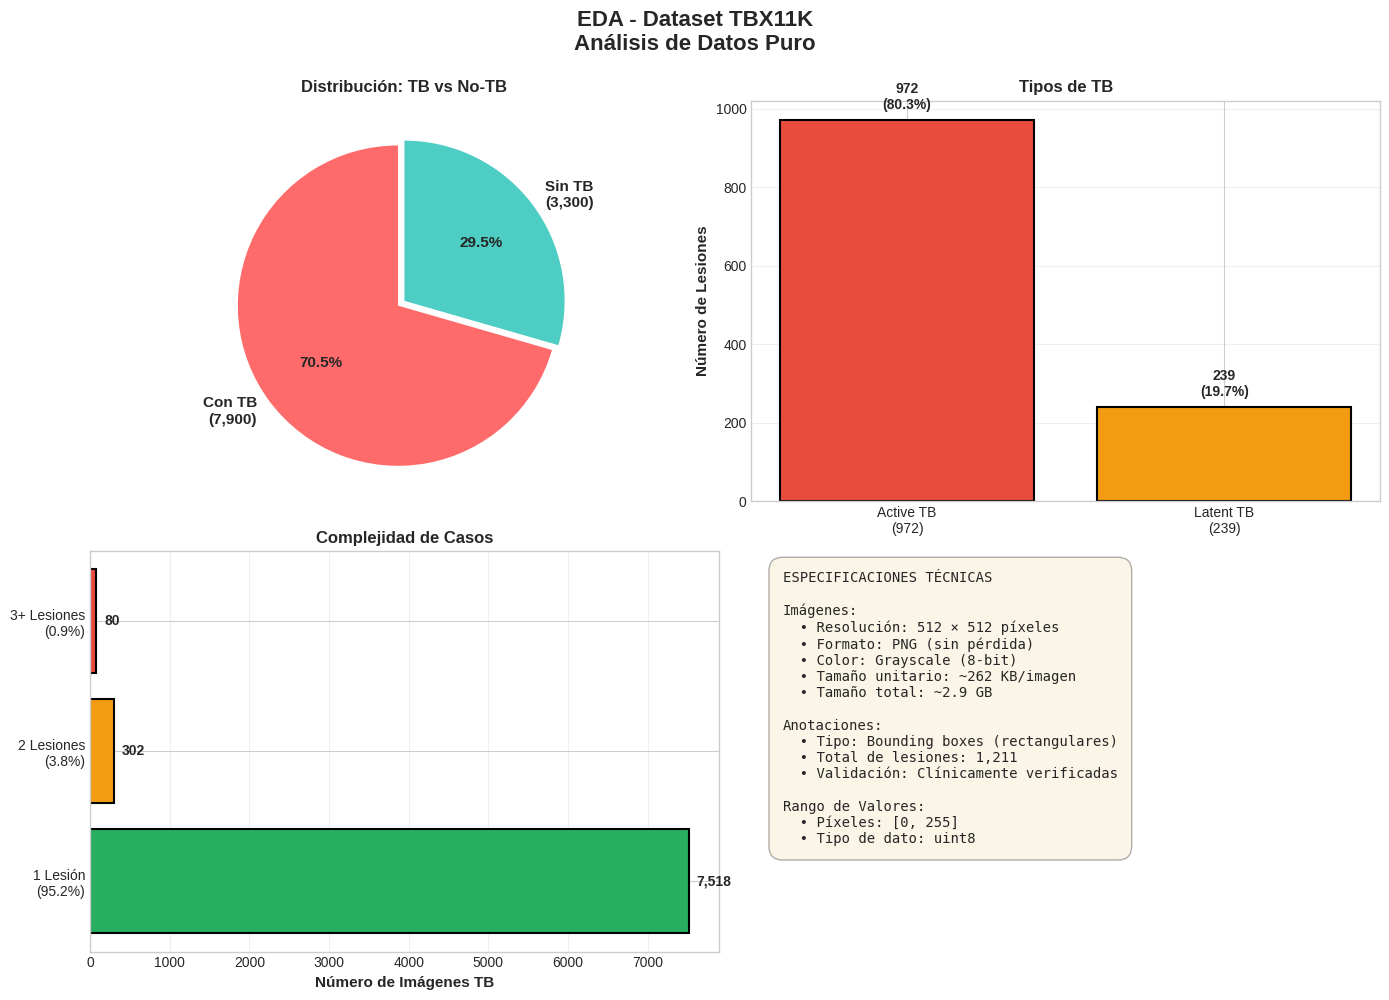

✅ Visualización completada


In [3]:
# Crear figura con visualizaciones principales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA - Dataset TBX11K\nAnálisis de Datos Puro',
             fontsize=16, fontweight='bold', y=0.995)

# 1. Distribución TB/No-TB
ax = axes[0, 0]
sizes = [7900, 3300]
labels = ['Con TB\n(7,900)', 'Sin TB\n(3,300)']
colors = ['#FF6B6B', '#4ECDC4']
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
       explode=(0.05, 0), startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax.set_title('Distribución: TB vs No-TB', fontweight='bold', fontsize=12)

# 2. Tipos de TB
ax = axes[0, 1]
tipos = ['Active TB\n(972)', 'Latent TB\n(239)']
valores = [972, 239]
colors_tb = ['#E74C3C', '#F39C12']
bars = ax.bar(tipos, valores, color=colors_tb, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Número de Lesiones', fontweight='bold', fontsize=11)
ax.set_title('Tipos de TB', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, valores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{val}\n({val*100/sum(valores):.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Múltiples Lesiones
ax = axes[1, 0]
lesiones = ['1 Lesión\n(95.2%)', '2 Lesiones\n(3.8%)', '3+ Lesiones\n(0.9%)']
cantidades = [7518, 302, 80]
colores = ['#27AE60', '#F39C12', '#E74C3C']
bars = ax.barh(lesiones, cantidades, color=colores, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Número de Imágenes TB', fontweight='bold', fontsize=11)
ax.set_title('Complejidad de Casos', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, cantidades):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontweight='bold', fontsize=10)

# 4. Especificaciones Técnicas
ax = axes[1, 1]
ax.axis('off')
specs_text = """ESPECIFICACIONES TÉCNICAS

Imágenes:
  • Resolución: 512 × 512 píxeles
  • Formato: PNG (sin pérdida)
  • Color: Grayscale (8-bit)
  • Tamaño unitario: ~262 KB/imagen
  • Tamaño total: ~2.9 GB

Anotaciones:
  • Tipo: Bounding boxes (rectangulares)
  • Total de lesiones: 1,211
  • Validación: Clínicamente verificadas

Rango de Valores:
  • Píxeles: [0, 255]
  • Tipo de dato: uint8"""
ax.text(0.05, 0.95, specs_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3, pad=1))

plt.tight_layout()
plt.show()

print(' Visualización completada')

##  Objetivos de Trabajo Futuro

### Objetivo General

> **Desarrollar un sistema automático de segmentación de lesiones TB en radiografías de tórax mediante técnicas de aprendizaje débilmente supervisado**, que permita:
>
> 1. Convertir anotaciones de bounding boxes en máscaras segmentadas precisas
> 2. Entrenar modelos de segmentación sin anotaciones píxel-a-píxel costosas
> 3. Facilitar diagnóstico asistido por computadora en entornos clínicos
> 4. Crear herramienta reutilizable para investigación en IA médica

### Objetivos Específicos

#### O.E.1: Preparación y Procesamiento de Datos
- Validar integridad de 11,200 radiografías
- Verificar formato PNG y dimensiones (512×512)
- Parsear y validar CSV de bounding boxes
- Crear splits: Train (85%), Val (10%), Test (5%)
- Calcular estadísticas de normalización

#### O.E.2: Generación de Máscaras de Entrenamiento
- Crear pseudomáscaras rectangulares desde bboxes
- Refinar usando métodos alternativos (GrabCut, SAM, etc.)
- Manejar múltiples lesiones por imagen
- Validación manual de calidad (~100 casos)
- Documentar mejoras vs baseline

#### O.E.3: Entrenamiento de Modelo Base
- Implementar U-Net 2D (encoder-decoder)
- Configurar loss functions ponderadas (Dice + Cross-entropy)
- Data augmentation y regularización
- Monitoreo de convergencia
- Guardado de checkpoints

#### O.E.4: Análisis de Resultados
- Calcular Dice, IoU, Sensibilidad, Especificidad
- Análisis por subgrupos (Active vs Latent TB)
- Análisis de errores (false positive/negative)
- Visualización de predicciones
- Redacción de reporte final


##  Métricas a Reportar

### A Nivel de Píxel (Segmentación)

| Métrica | Fórmula | Interpretación | Rango | Objetivo |
|---------|---------|---|-------|----------|
| **Dice** | 2\|X∩Y\|/(\|X\|+\|Y\|) | Solapamiento de máscaras | [0,1] | > 0.70 |
| **IoU** | \|X∩Y\|/\|X∪Y\| | Intersección/Unión | [0,1] | > 0.60 |
| **Sensibilidad** | TP/(TP+FN) | ¿Detecta lesiones reales? | [0,1] | > 0.80 |
| **Especificidad** | TN/(TN+FP) | ¿Evita falsos positivos? | [0,1] | > 0.85 |
| **Precisión** | TP/(TP+FP) | Confiabilidad predicciones | [0,1] | > 0.75 |
| **F1-Score** | 2×(P×R)/(P+R) | Balance precisión-recall | [0,1] | > 0.70 |

### A Nivel Clínico (Diagnóstico)

| Métrica | Significado | Importancia |
|---------|-------------|-------------|
| **VPP** | Si dice TB, ¿realmente hay TB? | Confianza positiva |
| **VPN** | Si dice sano, ¿realmente lo es? | Confianza negativa |
| **Sensibilidad Clínica** | ¿Identifica lesiones TB reales? | **CRÍTICA** - No perder casos |
| **Especificidad Clínica** | ¿Evita alarmas falsas? | Importante - Reduce sobrediagnóstico |
| **AUC-ROC** | Discriminación global | Rendimiento general del modelo |

### Análisis por Subgrupos

- Active TB vs Latent TB
- Lesiones pequeñas vs grandes
- Lesiones únicas vs múltiples
- Por ubicación anatómica
- Por calidad de imagen


##  Consideraciones Importantes

### Limitaciones del Dataset

 **Anotaciones Débiles**
- Bounding boxes son aproximadas (no contornos exactos)
- No representan lesiones pixel-perfectas
- Requieren refinamiento antes de usar como ground truth

 **Sesgo Geográfico**
- Dataset procede de región específica (China)
- Puede no representar patología TB en otras poblaciones
- Validación local es necesaria (especialmente en Atlántico, Colombia)

 **Variabilidad Técnica**
- Radiografías de múltiples equipos y centros
- Variación en técnica radiográfica
- Calidad heterogénea de imágenes
- Requiere normalización y data augmentation

 **Lesiones Pequeñas**
- Lesiones < 5% del área de imagen son difíciles de detectar
- Requiere arquitectura con buena resolución espacial
- Data augmentation crítica

### Desafíos Metodológicos

 **Desequilibrio de Clases**
```
En cada radiografía:
├─ Fondo (no-lesión):  ~450,000 píxeles (87%)
└─ Lesión:             ~60,000 píxeles (13%)

Problema: Modelo tiende a predecir "fondo" trivialmente
Solución: Loss functions ponderadas (Dice, Focal Loss)
```

 **Lesiones Ambiguas**
- Algunos infiltrados difusos no claramente TB
- Solapamiento con otras patologías
- Requiere validación clínica

 **Fusión de Lesiones Cercanas**
- Métodos de refinamiento pueden fusionar lesiones próximas
- Requiere post-procesamiento (watershed, etc.)

### CRÍTICO: No es Diagnóstico

 **Este modelo es ASISTENCIA MÉDICA, NO DIAGNÓSTICO**
- Requiere interpretación radiológica especializada
- No reemplaza especialista TB
- Validación clínica exhaustiva es obligatoria
- Requiere estudios de concordancia antes de uso clínico


##  Conclusiones

### Dataset TBX11K: Evaluación General

####  Fortalezas

1. **Dataset robusto y público**
   - 11,200 radiografías es cantidad suficiente para entrenar deep learning
   - Validación clínica de etiquetas
   - Disponible para investigación

2. **Anotaciones detalladas**
   - Bounding boxes permiten generar máscaras de entrenamiento
   - Múltiples lesiones por imagen soportadas
   - Diferenciación Active vs Latent TB

3. **Parámetros técnicos viables**
   - Resolución 512×512 es estándar en radiografía digital
   - Formato PNG sin pérdida asegura calidad
   - Grayscale simplifica procesamiento

4. **Problema bien definido**
   - Segmentación de TB es tarea médica importante
   - Tiene aplicaciones clínicas potenciales
   - Alineado con investigación internacional

####  Limitaciones

1. **Anotaciones débiles**
   - Bboxes ≠ máscaras precisas
   - Requiere refinamiento antes de usarse como ground truth

2. **Sesgo geográfico**
   - Dataset de región específica
   - Validación en contextos locales necesaria

3. **Variabilidad técnica**
   - Equipos y calidad heterogénea
   - Normalización cuidadosa requerida

4. **No es diagnóstico**
   - Es asistencia, no reemplaza especialista
   - Validación clínica es obligatoria



##  Referencias Bibliográficas

### Dataset Principal
- **Liu et al., 2020** - "Rethinking Computer-aided Tuberculosis Diagnosis"
  - CVPR 2020 (IEEE/CVF Conference)
  - DOI: 10.1109/CVPR42600.2020.01270
  - URL: http://mmcheng.net/tb/

### Arquitecturas Base
- **Ronneberger et al., 2015** - "U-Net: Convolutional Networks for Biomedical Image Segmentation"
  - MICCAI 2015
  - Arquitectura estándar para segmentación médica
  - DOI: 10.1007/978-3-319-24574-4_28

### Datasets Relacionados
- **Irvin et al., 2019** - CheXpert
  - 224K radiografías públicas
  - AAAI 2019
  
- **Wang et al., 2017** - ChestX-ray14
  - 112K radiografías públicas
  - Benchmark importante en radiografía de tórax

### Librerías y Herramientas
- **PyTorch**: Deep Learning Framework
- **OpenCV**: Computer Vision Library
- **scikit-learn**: Machine Learning Metrics
- **Pandas/NumPy**: Data Science
- **Matplotlib/Seaborn**: Data Visualization
